# Standard SVM - Lung Cancer Dataset

This notebook trains a standard (non-private) Support Vector Machine on the Lung Cancer dataset (50,000 samples, 23 features, 3-class target) to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Common SVM utilities shared across notebooks
# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics

from common_svm import StandardSVM, DifferentiallyPrivateSVM, DPSVMOneVsRest


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Classes: {sorted(set(y_train))}")

Training data shape: (40000, 23)
Test data shape: (10000, 23)
Classes: [np.int64(0), np.int64(1), np.int64(2)]


## 3. Train Standard SVM

In [3]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True  # Enable probability estimates for ROC-AUC
)

print("Training Standard SVM (RBF)...")
_t0 = time.perf_counter()
svm_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = svm_model.predict(X_train)
print("Training complete!")

Training Standard SVM (RBF)...


Training complete!


## 4. Model Evaluation

In [4]:
y_pred = svm_model.predict(X_test)

extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=svm_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("=" * 60)
print("STANDARD SVM - PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f} (weighted)")
print(f"Precision: {precision:.4f} (weighted)")
print(f"Recall:    {recall:.4f} (weighted)")
print("=" * 60)

STANDARD SVM - PERFORMANCE METRICS
Accuracy:  1.0000
F1-Score:  1.0000 (weighted)
Precision: 1.0000 (weighted)
Recall:    1.0000 (weighted)


## 5. Confusion Matrix

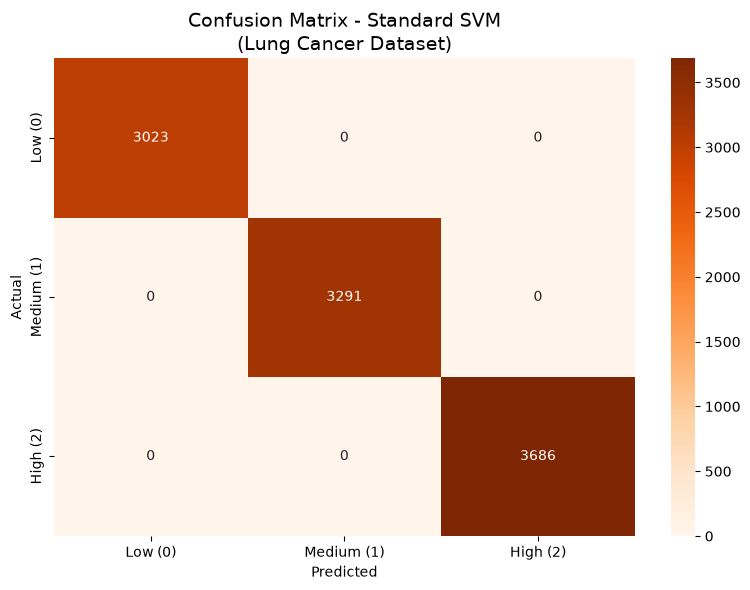

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.title('Confusion Matrix - Standard SVM\n(Lung Cancer Dataset)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6. Classification Report

In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Low (0)', 'Medium (1)', 'High (2)']))

Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00      3023
  Medium (1)       1.00      1.00      1.00      3291
    High (2)       1.00      1.00      1.00      3686

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 7. Save Baseline Results

In [7]:
os.makedirs('output', exist_ok=True)

baseline_results = {
    'model': 'Standard SVM (RBF)',
    'dataset': 'Lung Cancer',
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall
}
baseline_results.update(extra.means())

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('output/baseline_results.csv', index=False)

with open('output/std_svm_report.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("Results saved to output/baseline_results.csv")
print(f"\nBaseline Accuracy:  {accuracy:.4f}")
print(f"Baseline F1-Score:  {f1:.4f}")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(svm_model, 'output/model/std_svm_model.pkl')


print("Added metrics:")
print(extra.describe())

Results saved to output/baseline_results.csv

Baseline Accuracy:  1.0000
Baseline F1-Score:  1.0000


Model successfully exported to output/model/std_svm_model.pkl
Added metrics:
  Train Acc:      1.0000 ± 0.0000
  Balanced Acc:   1.0000 ± 0.0000
  AUROC:          1.0000 ± 0.0000
  Train Time (s): 0.4338 ± 0.0000
